In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import io
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

selector=files.upload() #abre el selector de archivos

#Empezamos con la EDA

archivo=list(selector.keys())[0] #obtiene solo el nombre de archivo y lo conviente a text

if archivo.lower().endswith('.csv'): #condicion de solo seleccionar archivos de tipo csv

  dataframe=pd.read_csv(io.BytesIO(selector[archivo]))
  print(dataframe.head()) #Se imprimen los 5 valores primeros

  print('Limpieza en ejecución....')
  #verificamos si el dataframe tiene valores nulos y guarda el resultado del nuevo
  df=dataframe.dropna()
  print('Limpieza completa')
  print('Dataframe sin valores nulos')
  print(df.isnull().any().any()) #Imprime false si existe algun valor vacio
  print(df)

  print('\nEstadísticas descriptivas')

  print(df.describe()) #Solo para las variables cuantitativas

  print("\nTipo de datos")
  print(df.info()) #Muestra la información de las variables y los tipos de datos





else:
  print('El archivo no es compatible') #si el archivo no es compatible, lanza este mensaje



Saving Burnout.csv to Burnout (12).csv
  Nacionalidad     Edad  Item1  Item2  Item3  Item4  Item5  Item6  Item7  \
0       Mexico  25 a 35      2      2      2      3      3      3      3   
1       Mexico  25 a 35      2      2      3      2      3      4      2   
2       Mexico  25 a 35      2      4      4      3      4      4      4   
3       Mexico  25 a 35      3      3      3      3      4      4      3   
4       Mexico  25 a 35      2      3      4      1      3      3      2   

   Item8  ...  Item21  Item22  Largas Jornadas Laborales  \
0      2  ...       2       4                          4   
1      2  ...       3       1                          4   
2      3  ...       3       1                          6   
3      3  ...       2       2                          6   
4      3  ...       2       2                          5   

   Funciones incorrectas  Sobrecarga laboral  Acoso laboral  Rotacion  \
0                     11                   9              5         6 

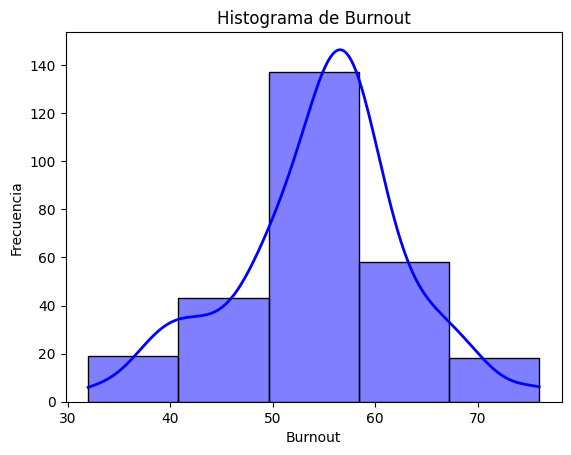

In [106]:
sns.histplot(df['Burnout'], bins=5, kde=True, color='blue', line_kws={'linestyle': '-', 'linewidth': 2}) #Se crea una hisograma para mostrar el conteo de las variables y la distribucion de las mismas

plt.xlabel('Burnout')
plt.ylabel('Frecuencia')
plt.title('Histograma de Burnout')
plt.show()

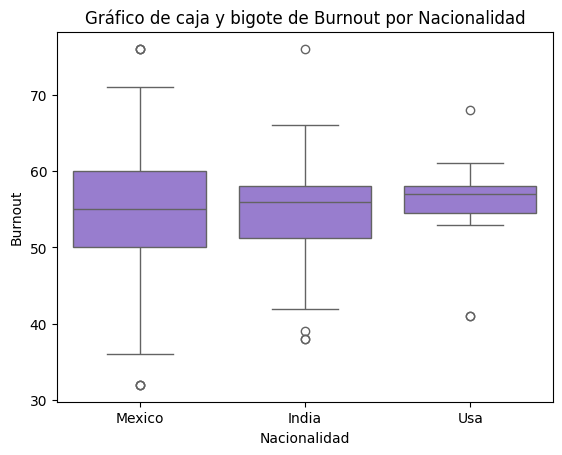

Métricas de dispersión por país:
                IQR
Nacionalidad       
India          6.75
Mexico        10.00
Usa            3.50


In [107]:
#Gráfico de caja y bigote

import numpy as np

sns.boxplot(x='Nacionalidad', y='Burnout', data=df, color='mediumpurple') #Se creó el diagrama de caja y bigote, en donde la variable dependiente es del burnout y la de agrupacion es la nacionalidad
plt.ylabel('Burnout')
plt.title('Gráfico de caja y bigote de Burnout por Nacionalidad')
plt.show()

#Calculo del rango intercuartil para ver la distribucion de los datos

agrupado = df.groupby('Nacionalidad')['Burnout'].quantile([0.25, 0.75]).unstack()
agrupado['IQR'] = agrupado[0.75] - agrupado[0.25]

# Mostrar los resultados
print("Métricas de dispersión por país:")
print(agrupado[['IQR']])

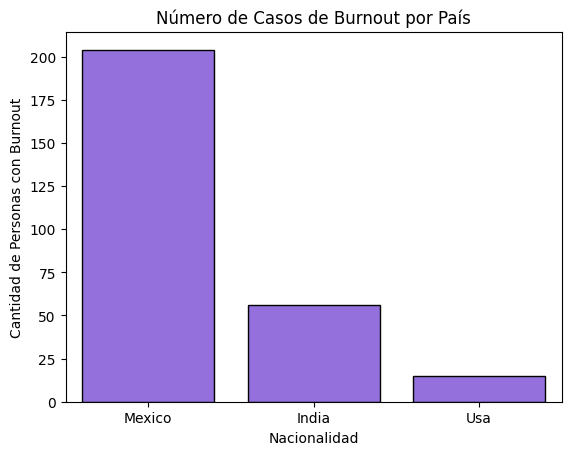

In [108]:
#Distribucion de grafico de barras por nacionalidad y burnout


# Graficar el conteo por país
sns.countplot(
    x='Nacionalidad',
    data=df,
    facecolor='mediumpurple', # Tu color elegante
    edgecolor='black',
    order=['Mexico', 'India', 'Usa'] # Ordenar las barras
)

plt.xlabel('Nacionalidad')
plt.ylabel('Cantidad de Personas con Burnout')
plt.title('Número de Casos de Burnout por País')
plt.show()


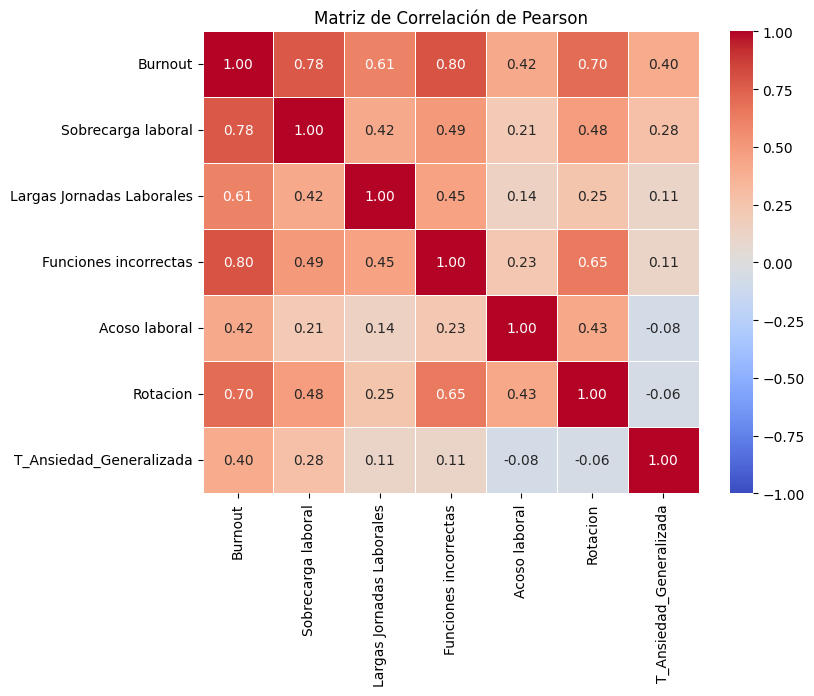

In [109]:
#Diagrama de correlacion de pearson

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Especifica aquí los nombres exactos de tus 5 variables continuas
# (Reemplaza estos nombres por los nombres reales de tus columnas en el df)
mis_variables = ['Burnout', 'Sobrecarga laboral', 'Largas Jornadas Laborales', 'Funciones incorrectas', 'Acoso laboral', 'Rotacion', 'T_Ansiedad_Generalizada']

# 2. Filtramos el DataFrame original para quedarnos solo con ellas
df_analisis = df[mis_variables]

# 3. Calculamos la matriz de Pearson
matriz = df_analisis.corr(method='pearson')

# 4. Diseñamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()

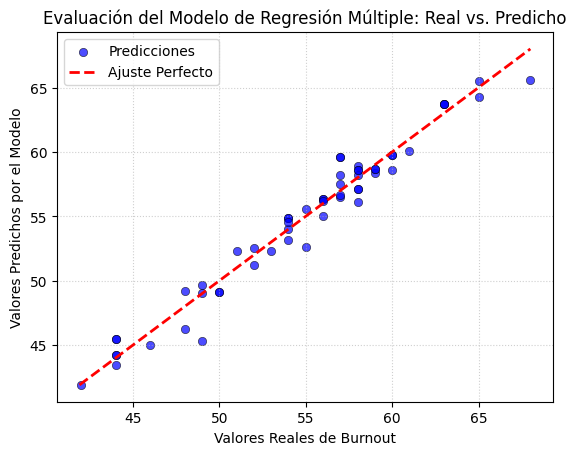

--- RESULTADOS DEL MODELO ---
Intersección (Alpha): 2.68
Coeficientes (Betas): {'Funciones incorrectas': np.float64(1.01), 'Sobrecarga laboral': np.float64(1.25), 'Rotacion': np.float64(0.93), 'Largas Jornadas Laborales': np.float64(1.24), 'Acoso laboral': np.float64(0.83), 'T_Ansiedad_Generalizada': np.float64(1.27)}
Error Cuadrático Medio (MSE): 1.33
Coeficiente de Determinación (R²): 0.96
Error Absoluto Medio (MAE): 1.33
Raíz del Error Cuadrático Medio (RMSE): 1.15


In [110]:
#Analisis de regresion multiple

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definir variables independientes (X) y dependiente (y)
predictores = ['Funciones incorrectas', 'Sobrecarga laboral', 'Rotacion', 'Largas Jornadas Laborales', 'Acoso laboral', 'T_Ansiedad_Generalizada']
X = df[predictores]
y = df['Burnout']

# 2. Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Realizar predicciones
y_pred = modelo.predict(X_test)

# 5. Guardar los coeficientes directamente en un diccionario sin usar ciclos
coeficientes = dict(zip(predictores, np.round(modelo.coef_, 2)))

#Se graficará el modelo con los valores reales vs los predichos

# 6. Graficar los puntos (Real vs Predicho)
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7, edgecolor='black', label='Predicciones')

# 7. Dibujar la línea de referencia ideal (diagonal perfecta de 45 grados)
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limites, limites, color='red', linestyle='--', linewidth=2, label='Ajuste Perfecto')

# 8. Personalizar textos y formato
plt.xlabel('Valores Reales de Burnout')
plt.ylabel('Valores Predichos por el Modelo')
plt.title('Evaluación del Modelo de Regresión Múltiple: Real vs. Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# . Mostrar la gráfica
plt.show()

print("--- RESULTADOS DEL MODELO ---")
print(f"Intersección (Alpha): {modelo.intercept_:.2f}")
print("Coeficientes (Betas):", coeficientes)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.2f}")
print(f"Error Absoluto Medio (MAE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


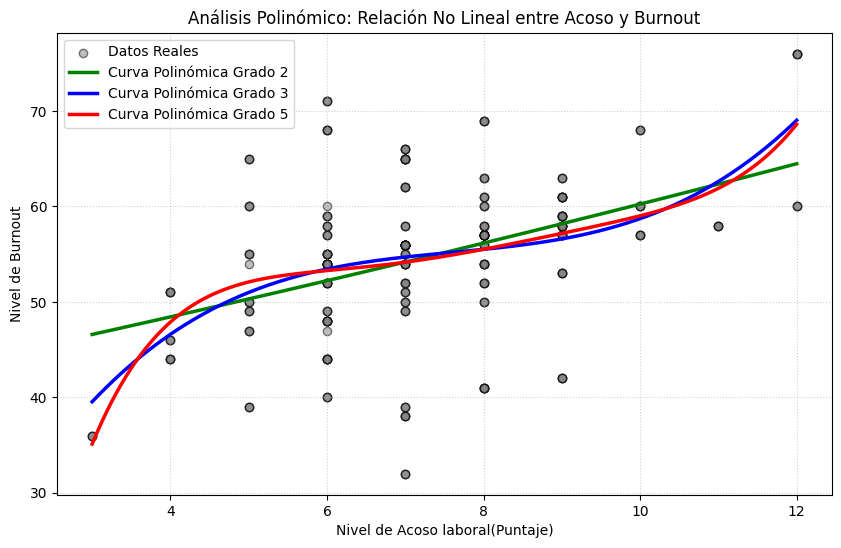

Métricas con Acoso laboral (Grado 2)
R²: 0.18
R² Ajustado: 0.17
MAE: 5.37
RMSE: 7.45

--- Métricas con Acoso laboral (Grado 3) ---
R²: 0.21
R² Ajustado: 0.20
MAE: 5.34
RMSE: 7.30

--- Métricas con Acoso laboral (Grado 5) ---
R²: 0.22
R² Ajustado: 0.20
MAE: 5.30
RMSE: 7.27


In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Aislamos la variable de salud mental
X_ansiedad = df[['Acoso laboral']]
y_burnout = df['Burnout']
n = len(df) # Define n here for R-squared adjusted calculation

# 2. Entrenamos los modelos polinómicos sobre los datos reales
poly2 = PolynomialFeatures(degree=2)
poly3 = PolynomialFeatures(degree=3)
poly5=PolynomialFeatures(degree=5)

X_p2 = poly2.fit_transform(X_ansiedad)
X_p3 = poly3.fit_transform(X_ansiedad)
X_p5= poly5.fit_transform(X_ansiedad)

grado2 = LinearRegression().fit(X_p2, y_burnout)
grado3 = LinearRegression().fit(X_p3, y_burnout)
grado5 = LinearRegression().fit(X_p5, y_burnout)

#

# 3. CREACIÓN DEL EJE CONTINUO: Esto es lo que suaviza la línea para que se vea la curva real
X_continuo = np.linspace(X_ansiedad.min(), X_ansiedad.max(), 300).reshape(-1, 1)

# 4. Predecimos sobre el eje continuo decimal
y_curva2 = grado2.predict(poly2.transform(X_continuo))
y_curva3 = grado3.predict(poly3.transform(X_continuo))
y_curva5=grado5.predict(poly5.transform(X_continuo))

#Calculo de las metricas

y_pred2 = grado2.predict(poly2.transform(X_ansiedad))
y_pred3 = grado3.predict(poly3.transform(X_ansiedad))
y_pred5=grado5.predict(poly5.transform(X_ansiedad))

# 5. Graficación
plt.figure(figsize=(10, 6))

# Puntos reales
plt.scatter(X_ansiedad, y_burnout, color='gray', alpha=0.5, edgecolor='black', label='Datos Reales')

# Líneas curvas continuas matemáticas
plt.plot(X_continuo, y_curva2, color='green', linewidth=2.5, label='Curva Polinómica Grado 2')
plt.plot(X_continuo, y_curva3, color='blue', linewidth=2.5, label='Curva Polinómica Grado 3')
plt.plot(X_continuo, y_curva5, color='red', linewidth=2.5, label='Curva Polinómica Grado 5')

#

plt.title("Análisis Polinómico: Relación No Lineal entre Acoso y Burnout")
plt.xlabel("Nivel de Acoso laboral(Puntaje)")
plt.ylabel("Nivel de Burnout")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- BLOQUE DE MÉTRICAS COMPLETO ---
print("Métricas con Acoso laboral (Grado 2)")
r2_2 = r2_score(y_burnout, y_pred2)
print(f"R²: {r2_2:.2f}")
print(f"R² Ajustado: {1-((1-r2_2)*(n-1)/(n-X_p2.shape[1]-1)):.2f}")
print(f"MAE: {mean_absolute_error(y_burnout, y_pred2):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_burnout, y_pred2)):.2f}")

print("\n--- Métricas con Acoso laboral (Grado 3) ---")
r2_3 = r2_score(y_burnout, y_pred3)
print(f"R²: {r2_3:.2f}")
print(f"R² Ajustado: {1-((1-r2_3)*(n-1)/(n-X_p3.shape[1]-1)):.2f}")
print(f"MAE: {mean_absolute_error(y_burnout, y_pred3):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_burnout, y_pred3)):.2f}")

print("\n--- Métricas con Acoso laboral (Grado 5) ---")
r2_5 = r2_score(y_burnout, y_pred5)
print(f"R²: {r2_5:.2f}")
print(f"R² Ajustado: {1-((1-r2_5)*(n-1)/(n-X_p5.shape[1]-1)):.2f}")
print(f"MAE: {mean_absolute_error(y_burnout, y_pred5):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_burnout, y_pred5)):.2f}")

--- MÉTRICAS DE CLASIFICACIÓN VECINOS MÁS CERCANOS (K-NN) ---
Exactitud (Accuracy): 0.80
Precisión (Precision): 0.85
Sensibilidad (Recall): 0.77
Puntaje F1 (F1-Score): 0.80

Reporte de Clasificación Detallado por Categoría:
              precision    recall  f1-score   support

        Alto       1.00      0.62      0.76        13
        Bajo       0.82      0.82      0.82        17
       Medio       0.73      0.88      0.80        25

    accuracy                           0.80        55
   macro avg       0.85      0.77      0.80        55
weighted avg       0.82      0.80      0.80        55



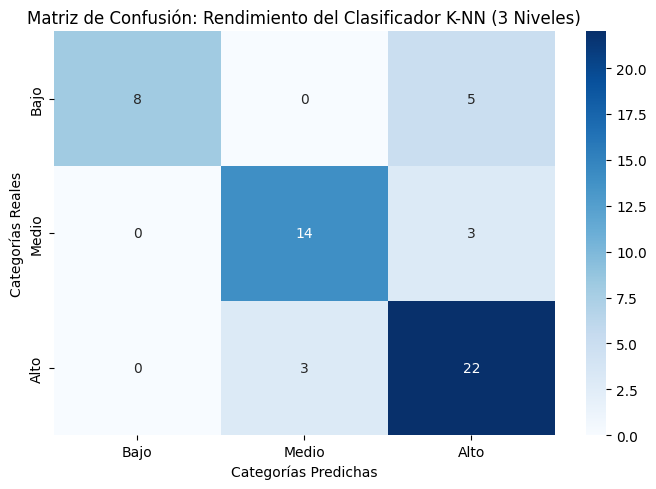

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# 1. TRANSFORMACIÓN DE LA VARIABLE OBJETIVO (CONVERSIÓN A BAJO, MEDIO, ALTO)

# Dividimos la variable continua en 3 grupos de igual tamaño utilizando terciles
df['Burnout'] = pd.qcut(df['Burnout'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Forzamos el orden lógico institucional para asegurar la correcta alineación de los ejes
df['Burnout'] = pd.Categorical(df['Burnout'], categories=['Bajo', 'Medio', 'Alto'], ordered=True)


# 2. DEFINICIÓN DE VARIABLES Y DIVISIÓN DE CONJUNTOS (TRAIN / TEST)

# Seleccionamos las 6 variables independientes del estudio
predictores_knn = ['Funciones incorrectas', 'Sobrecarga laboral', 'Rotacion',
                  'Largas Jornadas Laborales', 'Acoso laboral', 'T_Ansiedad_Generalizada']

X = df[predictores_knn]
y = df['Burnout'] # Variable objetivo ahora categórica estructurada

# Guardamos el tamaño total de la muestra
n = len(df)

# Dividimos en 80% para entrenamiento y 20% para la evaluación de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. ESCALAMIENTO CRÍTICO DE DATOS

# K-NN calcula distancias geométricas; por ende, requiere normalizar las escalas numéricas
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)


# 4. ENTRENAMIENTO DEL MODELO DE CLASIFICACIÓN K-NN

# Configuramos el clasificador con un valor estándar de K=5 vecinos
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_escalado, y_train)

# Generamos las predicciones categóricas sobre el conjunto de prueba
y_pred_knn = modelo_knn.predict(X_test_escalado)


# 5. CÁLCULO E IMPRESIÓN DE MÉTRICAS DE CLASIFICACIÓN

print("--- MÉTRICAS DE CLASIFICACIÓN VECINOS MÁS CERCANOS (K-NN) ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_knn, average='macro', zero_division=0):.2f}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_knn, average='macro', zero_division=0):.2f}")
print(f"Puntaje F1 (F1-Score): {f1_score(y_test, y_pred_knn, average='macro', zero_division=0):.2f}\n")

print("Reporte de Clasificación Detallado por Categoría:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# ==============================================================================
# 6. GRAFICACIÓN DE LA MATRIZ DE CONFUSIÓN (CUADRÍCULA 3x3)
# ==============================================================================
matriz_confusion = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7, 5))
# Generamos un mapa de calor sombreado en tonos azules para evaluar aciertos y fallos
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])

plt.title('Matriz de Confusión: Rendimiento del Clasificador K-NN (3 Niveles)')
plt.xlabel('Categorías Predichas')
plt.ylabel('Categorías Reales')
plt.tight_layout()
plt.show()

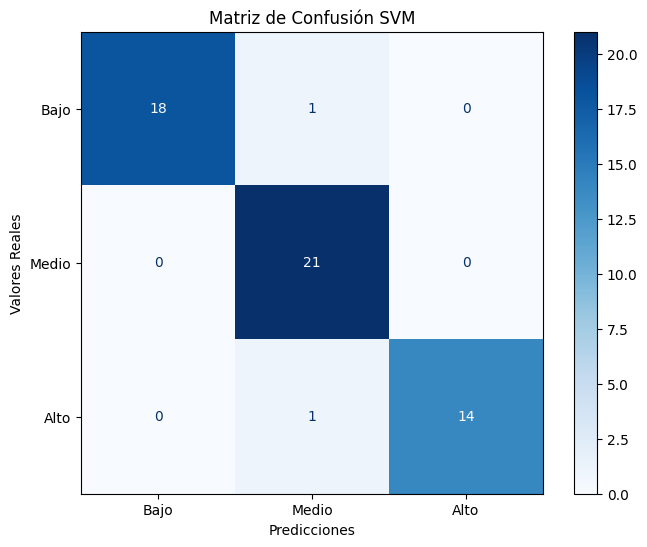


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        Bajo       1.00      0.93      0.97        15
       Medio       1.00      0.95      0.97        19
        Alto       0.91      1.00      0.95        21

    accuracy                           0.96        55
   macro avg       0.97      0.96      0.96        55
weighted avg       0.97      0.96      0.96        55



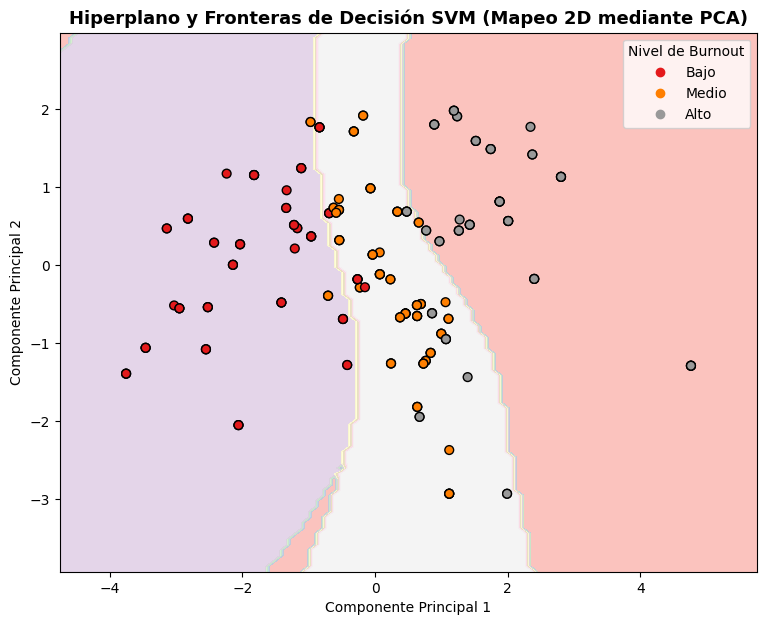

In [113]:
#Creación de la maquina de vectores de soporte

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC#se importa la libreria svm del paquete sklearn
from sklearn.metrics import accuracy_score #metricas para evaluar el modelo
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay #agregamos la libreria de confusion y la clasificacion en un reporte
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Seleccionamos la variable dependiente

variable_dependiente=df['Burnout']

# Seleccionamos las 6 variables independientes del estudio
predictores = ['Funciones incorrectas', 'Sobrecarga laboral', 'Rotacion',
                  'Largas Jornadas Laborales', 'Acoso laboral', 'T_Ansiedad_Generalizada']

X = df[predictores]



#Utilizamos el test size=0.2, que corresponde al 20% de los datos para prueba y el 80% restante en automatico para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, variable_dependiente, test_size=0.2, random_state=42, stratify=variable_dependiente) #El numero 42 permite sembrar la semilla para entrenar el modelo y eligiendo 42 veces la asignacion de numeros aleatorios


# Crear el escalador y ajustar con los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Creacion del modelo SVM

SVM=SVC(kernel='rbf', C=1.0) #El kernel RBF es una función que mide la similitud o "cercanía" entre dos puntos de datos en un espacio de características de dimensión infinita.
#Permite que los algoritmos tracen fronteras de decisión no lineales sin necesidad de mapear explícitamente los datos a dimensiones superiores.
#El valor c, tambien llamado codigo c igual a uno, permite tener mayor flexibilidad y evitar el sobreajuste de los datos, en donde los datos pueden estar cercanos entre lo vectores del modelo


# Entrenar el modelo con los datos escalados
SVM.fit(X_train_scaled, y_train)



#Se asignan los valores para prediccion

y_prediction=SVM.predict(X_test_scaled) #Se le asigna a la variable y o dependiente el entrenamiento del modelo a través de la variable x de prueba


#Creamos las clases del vector
clases_burnout =['Bajo', 'Medio', 'Alto']

#Calculamos y graficamos la matriz de confusion, ya que estamos clasfificando los datos en categorias

matrizsvm=confusion_matrix(y_test, y_prediction, labels=clases_burnout) #valores reales(y_test) vs predichos(valor de la variable dependiente)


#Transformar los datos en campos visuales

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matrizsvm, display_labels=clases_burnout)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('Matriz de Confusión SVM')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()

#Imprimir las metricas de confusion en la consola

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_prediction, target_names=clases_burnout)) #Imprimimos los valores dentro de las categorias. Si se omite esto, salen como 0, 1 y 2


#Utilizamos el pca para reduccion de las variables en solo 2

from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Reducir las 6 variables a solo 2 dimensiones para poder graficar
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 2. Reentrenar un modelo SVM rápido solo para propósitos de la gráfica 2D
svm_2d = SVC(kernel='rbf', C=1.0)
svm_2d.fit(X_train_pca, y_train)

# 3. Dibujar la frontera de decisión en las zonas de color
plt.figure(figsize=(9, 7))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_train_pca,
    response_method="predict",
    cmap=plt.cm.Pastel1,
    alpha=0.8,
    ax=ax
)

# 4. Mapear tus etiquetas de texto a números para los colores de los puntos
mapeo_numerico = {'Bajo': 0, 'Medio': 1, 'Alto': 2} # Corrected 'Moderado' to 'Medio'
y_train_num = y_train.map(mapeo_numerico)

# 5. Dibujar los puntos de los trabajadores sobre las regiones de decisión
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_num, cmap=plt.cm.Set1, edgecolors="k", s=40)

# Configurar leyenda y títulos profesionales
lineas, _ = scatter.legend_elements()
ax.legend(lineas, clases_burnout, loc="upper right", title="Nivel de Burnout")
plt.title("Hiperplano y Fronteras de Decisión SVM (Mapeo 2D mediante PCA)", fontsize=13, fontweight='bold')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()